In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 


reading data using pandas 

In [3]:
cols=['date','time','open','high','low','close','volume']
df = pd.read_csv("XAUUSD15(1).csv",names=cols)
df

,date,time,open,high,low,close,volume
0,2025.12.24,17:30,4469.46,4472.66,4449.61,4452.94,5593
1,2025.12.24,17:45,4452.55,4460.86,4448.33,4458.00,5518
2,2025.12.24,18:00,4457.99,4471.12,4455.82,4465.87,4078
3,2025.12.24,18:15,4465.86,4468.89,4464.03,4468.38,3517
4,2025.12.24,18:30,4468.43,4476.69,4467.19,4475.26,4003
...,...,...,...,...,...,...,...
2043,2026.01.28,08:30,5255.54,5264.56,5255.03,5261.61,3094
2044,2026.01.28,08:45,5261.71,5271.26,5257.08,5269.98,2903
2045,2026.01.28,09:00,5269.72,5275.34,5262.78,5273.65,3171
2046,2026.01.28,09:15,5273.20,5284.01,5272.64,5281.10,3035


In [7]:
df.columns 


Index(['date', 'time', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

some simple plots for the data 

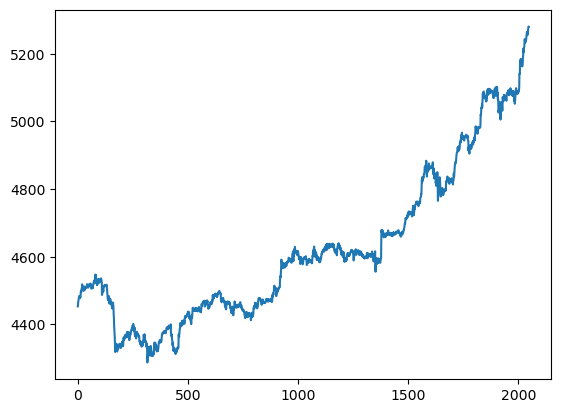

In [8]:
plt.plot(df.close)

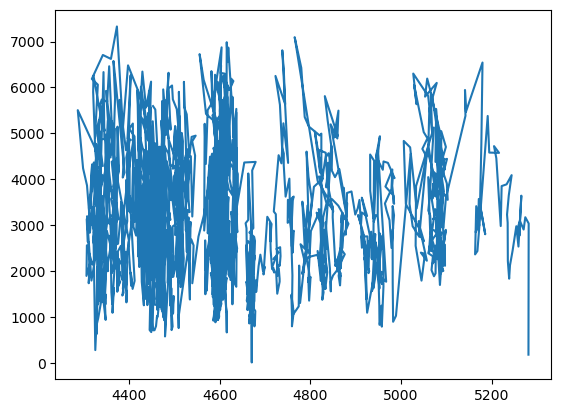

In [9]:
plt.plot(df.close, df['volume'])

In [10]:
df['body'] = df['close'] - df['open']
df['range'] = df['high'] - df['low']
df.head
df.tail 
df.describe


<bound method NDFrame.describe of             date   time     open     high      low    close  volume   body  \
0     2025.12.24  17:30  4469.46  4472.66  4449.61  4452.94    5593 -16.52   
1     2025.12.24  17:45  4452.55  4460.86  4448.33  4458.00    5518   5.45   
2     2025.12.24  18:00  4457.99  4471.12  4455.82  4465.87    4078   7.88   
3     2025.12.24  18:15  4465.86  4468.89  4464.03  4468.38    3517   2.52   
4     2025.12.24  18:30  4468.43  4476.69  4467.19  4475.26    4003   6.83   
...          ...    ...      ...      ...      ...      ...     ...    ...   
2043  2026.01.28  08:30  5255.54  5264.56  5255.03  5261.61    3094   6.07   
2044  2026.01.28  08:45  5261.71  5271.26  5257.08  5269.98    2903   8.27   
2045  2026.01.28  09:00  5269.72  5275.34  5262.78  5273.65    3171   3.93   
2046  2026.01.28  09:15  5273.20  5284.01  5272.64  5281.10    3035   7.90   
2047  2026.01.28  09:30  5281.00  5282.15  5278.59  5280.62     176  -0.38   

      range  
0     23.05  
1

In [11]:
df['open']

0       4469.46
1       4452.55
2       4457.99
3       4465.86
4       4468.43
         ...   
2043    5255.54
2044    5261.71
2045    5269.72
2046    5273.20
2047    5281.00
Name: open, Length: 2048, dtype: float64

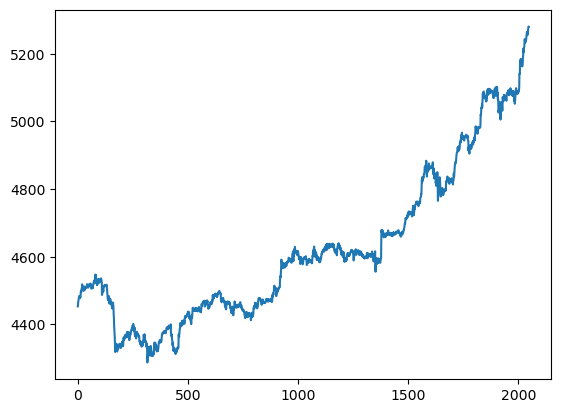

In [12]:
plt.plot(df['close'],label='closing_price')
#plt.plot(df['ma_20'])
#plt.plot(df['ma_50'])

Returns - logreturns is what is used since it mirrors exact . for simple returns p(t) -p(t-1)/p(t) *100%     
log returns = in{p(t)/p(t-1)}

In [13]:
df['simple_returns']=df['close'].pct_change()
df['log_returns']=np.log(df['close']/ df['close'].shift(1))
df['log_returns'].tail(4)

2044    0.001590
2045    0.000696
2046    0.001412
2047   -0.000091
Name: log_returns, dtype: float64

In [14]:
df['simple_returns'].tail(7)

2041    0.000257
2042   -0.001171
2043    0.001140
2044    0.001591
2045    0.000696
2046    0.001413
2047   -0.000091
Name: simple_returns, dtype: float64

In [15]:
df


,date,time,open,high,low,close,volume,body,range,simple_returns,log_returns
0,2025.12.24,17:30,4469.46,4472.66,4449.61,4452.94,5593,-16.52,23.05,NaN,NaN
1,2025.12.24,17:45,4452.55,4460.86,4448.33,4458.00,5518,5.45,12.53,0.001136,0.001136
2,2025.12.24,18:00,4457.99,4471.12,4455.82,4465.87,4078,7.88,15.30,0.001765,0.001764
3,2025.12.24,18:15,4465.86,4468.89,4464.03,4468.38,3517,2.52,4.86,0.000562,0.000562
4,2025.12.24,18:30,4468.43,4476.69,4467.19,4475.26,4003,6.83,9.50,0.001540,0.001539
...,...,...,...,...,...,...,...,...,...,...,...
2043,2026.01.28,08:30,5255.54,5264.56,5255.03,5261.61,3094,6.07,9.53,0.001140,0.001139
2044,2026.01.28,08:45,5261.71,5271.26,5257.08,5269.98,2903,8.27,14.18,0.001591,0.001590
2045,2026.01.28,09:00,5269.72,5275.34,5262.78,5273.65,3171,3.93,12.56,0.000696,0.000696
2046,2026.01.28,09:15,5273.20,5284.01,5272.64,5281.10,3035,7.90,11.37,0.001413,0.001412


In [4]:
duplicates =df.index.duplicated ().sum()
print("Duplicates observations",duplicates)
duplicate_row =df[df.index.duplicated(keep=False)]

Duplicates observations 0


Timestamp validation

In [13]:
print ("Index type :",type(df.index))
print("chronological order:",df.index.is_monotonic_increasing)
print("First timestamp",df.index.min())
print("last timestamp",df.index.max())

Index type : <class 'pandas.core.indexes.range.RangeIndex'>
chronological order: True
First timestamp 0
last timestamp 2047


In [10]:
invalid_ohlc=(
    (df['high']<df['open'])|
    (df['high']<df['close'])|
    (df['low']>df['open'])|
    (df['low']>df['close'])|
    (df['high']<df['low'])
)
print ('invalid ohlc rows:',invalid_ohlc.sum)

invalid ohlc rows: <bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
2043    False
2044    False
2045    False
2046    False
2047    False
Length: 2048, dtype: bool>


In [11]:
negative_volume=(df['volume']<0).sum()
print ("Negative volume observations ",negative_volume)

Negative volume observations  0


In [12]:
print(df.index)
print(type(df.index))
print(df.head())
print(df.columns)

RangeIndex(start=0, stop=2048, step=1)
<class 'pandas.core.indexes.range.RangeIndex'>
         date   time     open     high      low    close  volume
0  2025.12.24  17:30  4469.46  4472.66  4449.61  4452.94    5593
1  2025.12.24  17:45  4452.55  4460.86  4448.33  4458.00    5518
2  2025.12.24  18:00  4457.99  4471.12  4455.82  4465.87    4078
3  2025.12.24  18:15  4465.86  4468.89  4464.03  4468.38    3517
4  2025.12.24  18:30  4468.43  4476.69  4467.19  4475.26    4003
Index(['date', 'time', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
